# Assignment 1 - training pipeline

Online Shoppers Purchasing Intention (UCI dataset 468). Runs top to bottom with `uv run python main.py train` and saves everything the Gradio app needs into `artifacts/`.

## 1. Load the data

In [2]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
df = pd.read_csv(ROOT / "data" / "online_shoppers_intention.csv")
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. Explore before deciding anything

In [3]:
print(df.dtypes)
print("\nNull:", df.isna().sum().sum())
print("\nTasa de conversión global:", df["Revenue"].mean().round(4))
print(df["Revenue"].value_counts())

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

Null: 0

Tasa de conversión global: 0.1547
Revenue
False    10422
True      1908
Name: count, dtype: int64


,count,mean
Month,,
Feb,184,0.016304
Mar,1907,0.100682
May,3364,0.108502
June,288,0.100694
Jul,432,0.152778
Aug,433,0.175520
Sep,448,0.191964
Oct,549,0.209472
Nov,2998,0.253502


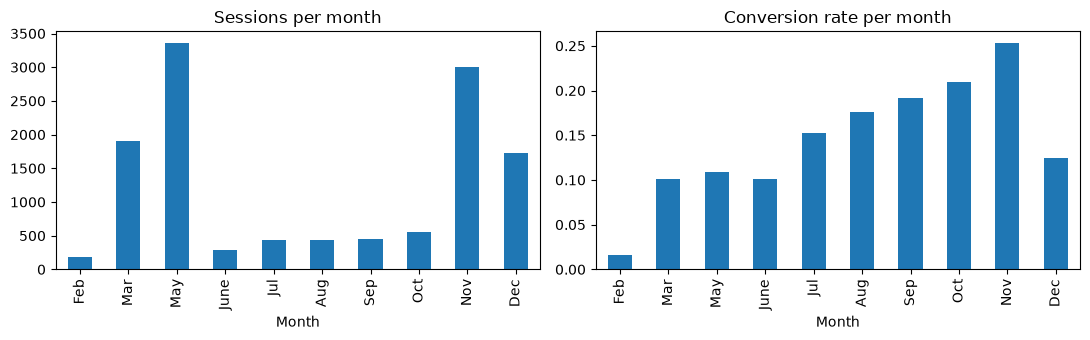

In [4]:
MONTHS = ["Feb","Mar","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]
by_month = (df.groupby("Month")["Revenue"]
              .agg(["count","mean"])
              .reindex(MONTHS))
display(by_month)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
by_month["count"].plot(kind="bar", ax=ax[0], title="Sessions per month")
by_month["mean"].plot(kind="bar", ax=ax[1], title="Conversion rate per month")
plt.tight_layout()

In [5]:
print(df.groupby("Revenue")["PageValues"].describe())
print("\n% de sesiones con PageValues == 0, per class:")
print(df.assign(zero=df["PageValues"].eq(0)).groupby("Revenue")["zero"].mean())

           count       mean        std  min       25%        50%        75%  \
Revenue                                                                       
False    10422.0   1.975998   9.072424  0.0  0.000000   0.000000   0.000000   
True      1908.0  27.264518  35.191954  0.0  3.641144  16.758134  38.897742   

                max  
Revenue              
False    246.758590  
True     361.763742  

% de sesiones con PageValues == 0, per class:
Revenue
False    0.885627
True     0.193920
Name: zero, dtype: float64


In [6]:
num = df.select_dtypes(include=[np.number]).columns.drop("Revenue", errors="ignore")
corr = df[num].corrwith(df["Revenue"]).sort_values(key=abs, ascending=False)
display(corr.to_frame("corr_with_Revenue"))

,corr_with_Revenue
PageValues,0.492569
ExitRates,-0.207071
ProductRelated,0.158538
ProductRelated_Duration,0.152373
BounceRates,-0.150673
Administrative,0.138917
Informational,0.095200
Administrative_Duration,0.093587
SpecialDay,-0.082305
Informational_Duration,0.070345


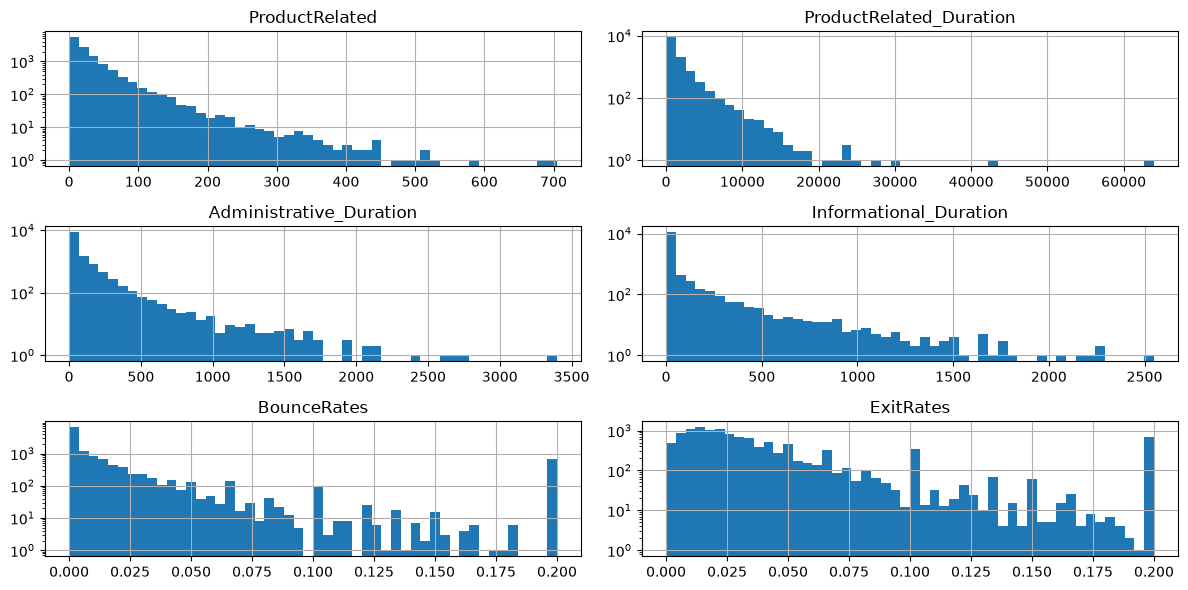

In [7]:
cols = ["ProductRelated","ProductRelated_Duration","Administrative_Duration",
        "Informational_Duration","BounceRates","ExitRates"]
df[cols].hist(bins=50, figsize=(12, 6), log=True)
plt.tight_layout()

## 3. Feature engineering

In [8]:
# --- Feature engineering -------------------------------------------------
EPS = 1e-6
USE_PAGE_VALUES = True   # ablation switch: run the whole notebook with True, then False

PAGE_PAIRS = {
    "admin":   ("Administrative",  "Administrative_Duration"),
    "info":    ("Informational",   "Informational_Duration"),
    "product": ("ProductRelated",  "ProductRelated_Duration"),
}

def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Session-level features available ~100s into the visit."""
    out = data.copy()

    # 1) Browsing intensity: seconds spent per page of each type.
    #    Separates careful readers from users bouncing through pages.
    for name, (count_col, dur_col) in PAGE_PAIRS.items():
        out[f"{name}_sec_per_page"] = out[dur_col] / (out[count_col] + EPS)

    # 2) Session composition: how much of the visit is product browsing.
    total_pages = (out["Administrative"] + out["Informational"]
                   + out["ProductRelated"])
    out["total_pages"] = total_pages
    out["product_page_share"] = out["ProductRelated"] / (total_pages + EPS)

    # 3) Log transform for heavy-tailed counts and durations.
    skewed = (
        [c for c in out.columns if c.endswith("_Duration")]
        + ["Administrative", "Informational", "ProductRelated", "total_pages"]
        + [f"{n}_sec_per_page" for n in PAGE_PAIRS]
    )
    for col in skewed:
        out[col] = np.log1p(out[col].clip(lower=0))

    # 4) PageValues ablation: it is derived from pages seen before a completed
    #    transaction, so it leaks the outcome in a live-scoring setting.
    if not USE_PAGE_VALUES:
        out = out.drop(columns=["PageValues"])

    # IDs, not magnitudes: encode them as categories, not numbers.
    for col in ["OperatingSystems", "Browser", "Region", "TrafficType"]:
        out[col] = out[col].astype(str)

    # Month drives the split, so it cannot also be a feature: the test months
    # would be categories the model never saw during training.
    out = out.drop(columns=["Month"])
    return out

X_all = engineer_features(df.drop(columns=["Revenue"]))
y_all = df["Revenue"].astype(int).to_numpy()
print(X_all.shape)
X_all.head()

(12330, 21)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,VisitorType,Weekend,admin_sec_per_page,info_sec_per_page,product_sec_per_page,total_pages,product_page_share
0,0.0,0.0,0.0,0.0,0.693147,0.000000,0.20,0.20,0.0,0.0,...,1,1,1,Returning_Visitor,False,0.0,0.0,0.000000,0.693147,0.999999
1,0.0,0.0,0.0,0.0,1.098612,4.174387,0.00,0.10,0.0,0.0,...,2,1,2,Returning_Visitor,False,0.0,0.0,3.496507,1.098612,1.000000
2,0.0,0.0,0.0,0.0,0.693147,0.000000,0.20,0.20,0.0,0.0,...,1,9,3,Returning_Visitor,False,0.0,0.0,0.000000,0.693147,0.999999
3,0.0,0.0,0.0,0.0,1.098612,1.299283,0.05,0.14,0.0,0.0,...,2,2,4,Returning_Visitor,False,0.0,0.0,0.847298,1.098612,1.000000
4,0.0,0.0,0.0,0.0,2.397895,6.443336,0.02,0.05,0.0,0.0,...,3,1,4,Returning_Visitor,True,0.0,0.0,4.154969,2.397895,1.000000


## 4. Time-based split (train / validation / test)

In [9]:
# --- Time-based split: train / validation / test -------------------------
TRAIN_MONTHS = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep"]
VAL_MONTHS   = ["Oct"]           # used only to pick the decision threshold
TEST_MONTHS  = ["Nov", "Dec"]    # never touched until the final numbers

train_mask = df["Month"].isin(TRAIN_MONTHS).to_numpy()
val_mask   = df["Month"].isin(VAL_MONTHS).to_numpy()
test_mask  = df["Month"].isin(TEST_MONTHS).to_numpy()

X_train, X_val, X_test = X_all[train_mask], X_all[val_mask], X_all[test_mask]
y_train, y_val, y_test = y_all[train_mask], y_all[val_mask], y_all[test_mask]

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s}: {len(yy):5d} rows, conversion {yy.mean():.3f}")

train: 7605 rows, conversion 0.123
test:  4725 rows, conversion 0.207


## 5. Preprocessing

In [10]:
# --- Preprocessing (fitted on train only) --------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

A_train = preprocessor.fit_transform(X_train).astype(np.float32)
A_val   = preprocessor.transform(X_val).astype(np.float32)
A_test  = preprocessor.transform(X_test).astype(np.float32)
print(A_train.shape, A_val.shape, A_test.shape)

(7605, 70) (4725, 70)


/tmp/ipykernel_2167/3424465899.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()


## 6. The same logistic regression, three ways

In [11]:
# --- Model 1: scikit-learn -----------------------------------------------
from sklearn.linear_model import LogisticRegression

C_REG = 1.0          # inverse regularisation strength
sk_model = LogisticRegression(C=C_REG, max_iter=1000)
sk_model.fit(A_train, y_train)
p_sk_val  = sk_model.predict_proba(A_val)[:, 1]
p_sk_test = sk_model.predict_proba(A_test)[:, 1]
print("sklearn trained:", A_train.shape[1], "coefficients")

sklearn trained: 70 coefficients


In [12]:
# --- Model 2: manual PyTorch loop ----------------------------------------
import torch
import torch.nn.functional as F

torch.manual_seed(42)
Xtr = torch.from_numpy(A_train)
Xva = torch.from_numpy(A_val)
Xte = torch.from_numpy(A_test)
ytr = torch.from_numpy(y_train.astype(np.float32))

n_features = Xtr.shape[1]
W = torch.zeros(n_features, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

LR = 0.5
EPOCHS = 2000
WEIGHT_DECAY = 1.0 / (C_REG * len(ytr))   # L2 comparable to the sklearn C

for epoch in range(EPOCHS):
    logits = (Xtr @ W + b).squeeze(1)
    loss = -(ytr * F.logsigmoid(logits) + (1 - ytr) * F.logsigmoid(-logits)).mean()
    loss = loss + WEIGHT_DECAY * (W ** 2).sum()

    loss.backward()
    with torch.no_grad():
        W -= LR * W.grad
        b -= LR * b.grad
        W.grad.zero_()
        b.grad.zero_()

    if epoch % 400 == 0:
        print(f"epoch {epoch:5d}  loss {loss.item():.4f}")

with torch.no_grad():
    p_manual_val  = torch.sigmoid(Xva @ W + b).squeeze(1).numpy()
    p_manual_test = torch.sigmoid(Xte @ W + b).squeeze(1).numpy()

epoch     0  loss 0.6931
epoch   400  loss 0.2300
epoch   800  loss 0.2296
epoch  1200  loss 0.2294
epoch  1600  loss 0.2292


In [13]:
# --- Model 3: standard PyTorch (nn.Module + optim) -----------------------
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

class LogisticRegressionNet(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x).squeeze(1)

net = LogisticRegressionNet(n_features)
optimiser = torch.optim.Adam(net.parameters(), lr=0.01, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()
loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=256, shuffle=True)

for epoch in range(60):
    for xb, yb in loader:
        optimiser.zero_grad()
        loss = criterion(net(xb), yb)
        loss.backward()
        optimiser.step()
    if epoch % 15 == 0:
        print(f"epoch {epoch:3d}  last batch loss {loss.item():.4f}")

net.eval()
with torch.no_grad():
    p_standard_val  = torch.sigmoid(net(Xva)).numpy()
    p_standard_test = torch.sigmoid(net(Xte)).numpy()

epoch   0  last batch loss 0.2993
epoch  15  last batch loss 0.1984
epoch  30  last batch loss 0.2537
epoch  45  last batch loss 0.2095


## 7. Comparison and business threshold

In [14]:
# --- Comparison: threshold picked on validation, value reported on test ---
from sklearn.metrics import roc_auc_score, average_precision_score

COUPON_COST = 8.0     # discount handed to someone who was going to buy anyway
RECOVERY_GAIN = 1.0   # 5% recovery rate x 20 EUR net margin

def business_value(y_true, probs, threshold):
    """Coupon fires when predicted purchase probability < threshold."""
    fires = probs < threshold
    gained = RECOVERY_GAIN * ((y_true == 0) & fires).sum()
    wasted = COUPON_COST * ((y_true == 1) & fires).sum()
    return gained - wasted

val_preds = {"sklearn": p_sk_val, "manual_torch": p_manual_val,
             "standard_torch": p_standard_val}
test_preds = {"sklearn": p_sk_test, "manual_torch": p_manual_test,
              "standard_torch": p_standard_test}

grid = np.linspace(0.01, 0.99, 99)
rows = []
for name in test_preds:
    val_values = [business_value(y_val, val_preds[name], t) for t in grid]
    chosen_t = float(grid[int(np.argmax(val_values))])
    p = test_preds[name]
    rows.append({
        "model": name,
        "auc": roc_auc_score(y_test, p),
        "avg_precision": average_precision_score(y_test, p),
        "threshold_from_val": chosen_t,
        "net_value_test_eur": float(business_value(y_test, p, chosen_t)),
    })

rows.append({"model": "baseline_coupon_to_everyone", "auc": 0.5,
             "avg_precision": float(y_test.mean()), "threshold_from_val": np.nan,
             "net_value_test_eur": float(RECOVERY_GAIN * (y_test == 0).sum()
                                         - COUPON_COST * (y_test == 1).sum())})

comparison = pd.DataFrame(rows).round(4)
display(comparison)

,model,auc,avg_precision,best_threshold,net_value_eur
0,sklearn,0.8397,0.6158,0.07,1224.0
1,manual_torch,0.8402,0.6156,0.07,1215.0
2,standard_torch,0.8411,0.6152,0.07,1265.0
3,baseline_coupon_to_everyone,0.5000,0.2066,NaN,-4059.0


## 8. Save artifacts for the dashboard

In [15]:
# --- Save artifacts ------------------------------------------------------
import json, joblib

ART = ROOT / "artifacts"
ART.mkdir(exist_ok=True)

joblib.dump(preprocessor, ART / "preprocessor.joblib")
joblib.dump(sk_model, ART / "model_sklearn.joblib")
torch.save({"W": W.detach(), "b": b.detach()}, ART / "model_manual.pt")
torch.save(net.state_dict(), ART / "model_standard.pt")

np.savez(ART / "test_predictions.npz", y_true=y_test, **test_preds)
X_test.to_csv(ART / "X_test.csv", index=False)
comparison.to_csv(ART / "comparison.csv", index=False)
(ART / "config.json").write_text(json.dumps({
    "coupon_cost": COUPON_COST,
    "recovery_gain": RECOVERY_GAIN,
    "use_page_values": USE_PAGE_VALUES,
    "train_months": TRAIN_MONTHS,
    "val_months": VAL_MONTHS,
    "test_months": TEST_MONTHS,
    "default_threshold": float(comparison.loc[0, "threshold_from_val"]),
    "n_features": int(n_features),
}, indent=2))
print("saved to", ART)

saved to /workspaces/daiist-assignment-1/artifacts
